# World Data in Polars

Cell-based Polars version of the original pandas notebook, matching the PySpark analysis flow.

In [1]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import polars as pl

DATA_DIR = Path(r"D:\Files\Documents\GitHub\world-data\data")

def clean_column_names(df: pl.DataFrame) -> pl.DataFrame:
    return df.rename({column: column.strip() for column in df.columns})

def read_csv(filename: str) -> pl.DataFrame:
    return clean_column_names(pl.read_csv(DATA_DIR / filename))

## Load CSV Files

In [2]:
names = read_csv("country_name.csv")
areas = read_csv("country_area.csv")
iso = read_csv("country_name_iso_3166.csv")
pop = read_csv("country_population.csv").rename({"year": "population_year"})
gdp = read_csv("country_gdp.csv").rename({"year": "gdp_year"})

pl.DataFrame(
    {
        "table": ["names", "areas", "iso", "pop", "gdp"],
        "rows": [names.height, areas.height, iso.height, pop.height, gdp.height],
        "columns": [names.width, areas.width, iso.width, pop.width, gdp.width],
    }
)

table,rows,columns
str,i64,i64
"""names""",197,3
"""areas""",195,3
"""iso""",249,5
"""pop""",215,3
"""gdp""",191,3


## Join and Derive Fields

In [3]:
df = (
    iso.join(names, on="alpha_3_code", how="left")
    .join(areas, on="alpha_3_code", how="left")
    .join(pop, on="alpha_3_code", how="left")
    .join(gdp, on="alpha_3_code", how="left")
    .with_columns(
        total_area=pl.col("land") + pl.col("water").fill_null(0),
        pop_density=pl.when(pl.col("land") > 0)
        .then(pl.col("population") / pl.col("land"))
        .otherwise(None),
    )
)

df.head()

english_short_name,french_short_name,alpha_2_code,alpha_3_code,numeric,common_english_name,official_country_name,land,water,population,population_year,gdp_usd,gdp_year,total_area,pop_density
str,str,str,str,i64,str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""Afghanistan""","""Afghanistan (l')""","""AF""","""AFG""",4,"""Afghanistan""","""Islamic Republic of Afghanista…",652230,630,42647492,2024,null,null,652860,65.387198
"""Albania""","""Albanie (l')""","""AL""","""ALB""",8,"""Albania""","""Republic of Albania""",27400,330,2377128,2024,27046429296,2024,27730,86.756496
"""Algeria""","""Algérie (l')""","""DZ""","""DZA""",12,"""Algeria""","""People's Democratic Republic o…",2381741,0,46814308,2024,269322281664,2024,2381741,19.655499
"""American Samoa""","""Samoa américaines (les)""","""AS""","""ASM""",16,null,null,null,null,46765,2024,null,null,null,null
"""Andorra""","""Andorre (l')""","""AD""","""AND""",20,"""Andorra""","""Principality of Andorra""",468,0,81938,2024,4039842405,2024,468,175.081197


## Land Area

In [4]:
# 10 largest countries by land area
df.sort("land", descending=True, nulls_last=True).select(
    "english_short_name", "alpha_3_code", "land", "water"
).head(10)

english_short_name,alpha_3_code,land,water
str,str,i64,i64
"""Russian Federation (the)""","""RUS""",16378410,719836
"""China""","""CHN""",9326410,270550
"""United States of America (the)""","""USA""",9147593,685924
"""Canada""","""CAN""",9093507,891163
"""Brazil""","""BRA""",8460415,55352
"""Australia""","""AUS""",7682300,58920
"""India""","""IND""",2973190,314070
"""Argentina""","""ARG""",2736690,43710
"""Kazakhstan""","""KAZ""",2699700,25202


In [5]:
# 10 smallest countries by land area, excluding zero/unknown
df.filter(pl.col("land") > 0).sort("land").select(
    "english_short_name", "alpha_3_code", "land", "water"
).head(10)

english_short_name,alpha_3_code,land,water
str,str,i64,i64
"""Monaco""","""MCO""",2,0
"""Nauru""","""NRU""",21,0
"""Tuvalu""","""TUV""",26,0
"""San Marino""","""SMR""",61,0
"""Liechtenstein""","""LIE""",160,0
"""Marshall Islands (the)""","""MHL""",181,0
"""Saint Kitts and Nevis""","""KNA""",261,0
"""Maldives""","""MDV""",298,0
"""Malta""","""MLT""",316,0


In [6]:
top20_land = (
    df.sort("land", descending=True, nulls_last=True)
    .head(20)
    .sort("land")
    .select("english_short_name", (pl.col("land") / 1_000_000).alias("land_million_km2"))
)

top20_land

english_short_name,land_million_km2
str,f64
"""Niger (the)""",1.2667
"""Peru""",1.279996
"""Iran (Islamic Republic of)""",1.531595
"""Mongolia""",1.553556
"""Sudan (the)""",1.731671
…,…
"""Brazil""",8.460415
"""Canada""",9.093507
"""United States of America (the)""",9.147593


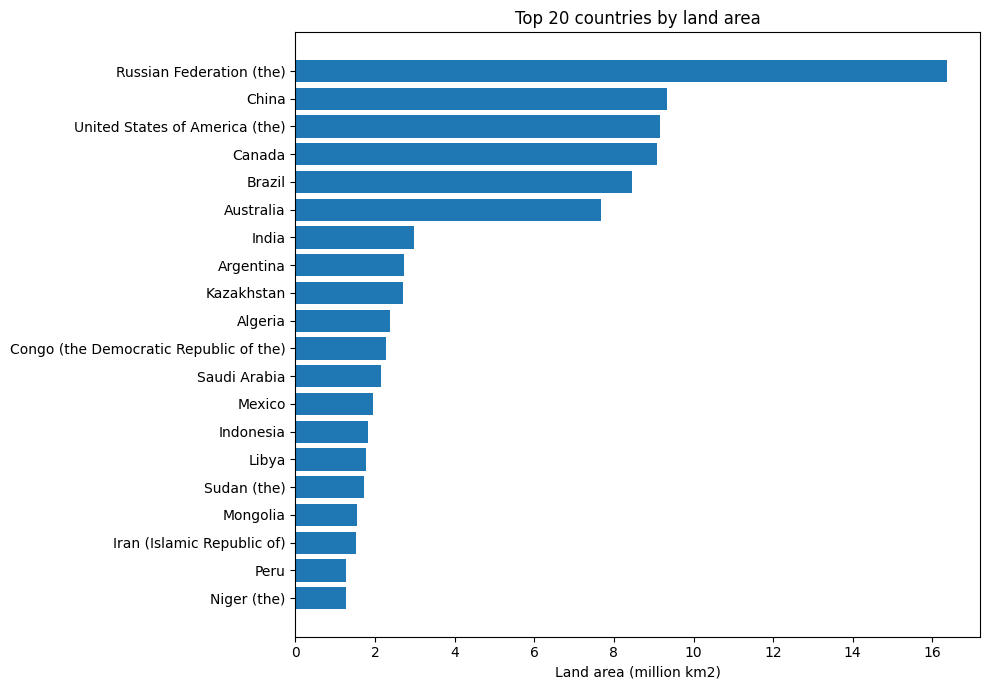

In [7]:
pdf = top20_land.to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["land_million_km2"])
ax.set_xlabel("Land area (million km2)")
ax.set_title("Top 20 countries by land area")
plt.tight_layout()
plt.show()

## Population

In [8]:
# 10 most populous countries
df.sort("population", descending=True, nulls_last=True).select(
    "english_short_name", "alpha_3_code", "population", "population_year"
).head(10)

english_short_name,alpha_3_code,population,population_year
str,str,i64,i64
"""India""","""IND""",1450935791,2024
"""China""","""CHN""",1408975000,2024
"""United States of America (the)""","""USA""",340110988,2024
"""Indonesia""","""IDN""",283487931,2024
"""Pakistan""","""PAK""",251269164,2024
"""Nigeria""","""NGA""",232679478,2024
"""Brazil""","""BRA""",211998573,2024
"""Bangladesh""","""BGD""",173562364,2024
"""Russian Federation (the)""","""RUS""",143533851,2024


In [9]:
# 10 least populous countries, excluding zero/null
df.filter(pl.col("population") > 0).sort("population").select(
    "english_short_name", "alpha_3_code", "population", "population_year"
).head(10)

english_short_name,alpha_3_code,population,population_year
str,str,i64,i64
"""Tuvalu""","""TUV""",9646,2024
"""Nauru""","""NRU""",11947,2024
"""Palau""","""PLW""",17695,2024
"""Saint Martin (French part)""","""MAF""",26129,2024
"""San Marino""","""SMR""",33977,2024
"""Marshall Islands (the)""","""MHL""",37548,2024
"""Monaco""","""MCO""",38631,2024
"""Gibraltar""","""GIB""",39329,2024
"""Virgin Islands (British)""","""VGB""",39471,2024


In [10]:
top20_population = (
    df.sort("population", descending=True, nulls_last=True)
    .head(20)
    .sort("population")
    .select("english_short_name", (pl.col("population") / 1_000_000).alias("population_millions"))
)

top20_population

english_short_name,population_millions
str,f64
"""Thailand""",71.668011
"""Germany""",83.516593
"""Türkiye""",85.518661
"""Iran (Islamic Republic of)""",91.567738
"""Viet Nam""",100.987686
…,…
"""Pakistan""",251.269164
"""Indonesia""",283.487931
"""United States of America (the)""",340.110988


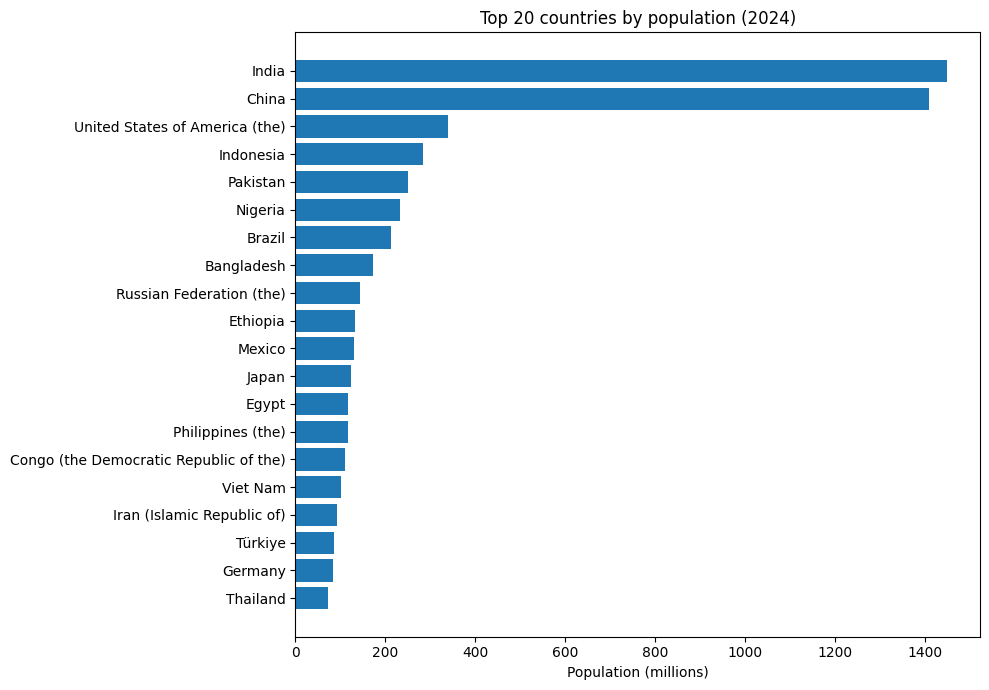

In [11]:
pdf = top20_population.to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["population_millions"])
ax.set_xlabel("Population (millions)")
ax.set_title("Top 20 countries by population (2024)")
plt.tight_layout()
plt.show()

## Population Density

In [12]:
df.filter(pl.col("land") > 0).sort("pop_density", descending=True, nulls_last=True).select(
    "english_short_name",
    "alpha_3_code",
    "population",
    "land",
    pl.col("pop_density").round(1),
).head(10)

english_short_name,alpha_3_code,population,land,pop_density
str,str,i64,i64,f64
"""Monaco""","""MCO""",38631,2,19315.5
"""Singapore""","""SGP""",6036860,716,8431.4
"""Bahrain""","""BHR""",1588670,778,2042.0
"""Malta""","""MLT""",568847,316,1800.1
"""Maldives""","""MDV""",527799,298,1771.1
"""Bangladesh""","""BGD""",173562364,130170,1333.4
"""Palestine, State of""","""PSE""",5289152,6000,881.5
"""Barbados""","""BRB""",282467,431,655.4
"""Mauritius""","""MUS""",1245779,2030,613.7


In [13]:
top20_density = (
    df.filter(pl.col("land") > 0)
    .sort("pop_density", descending=True, nulls_last=True)
    .head(20)
    .sort("pop_density")
    .select("english_short_name", "pop_density")
)

top20_density

english_short_name,pop_density
str,f64
"""Haiti""",427.160994
"""Israel""",463.990324
"""Comoros (the)""",465.678667
"""India""",488.006414
"""Korea (the Republic of)""",517.982014
…,…
"""Maldives""",1771.137584
"""Malta""",1800.148734
"""Bahrain""",2041.992288


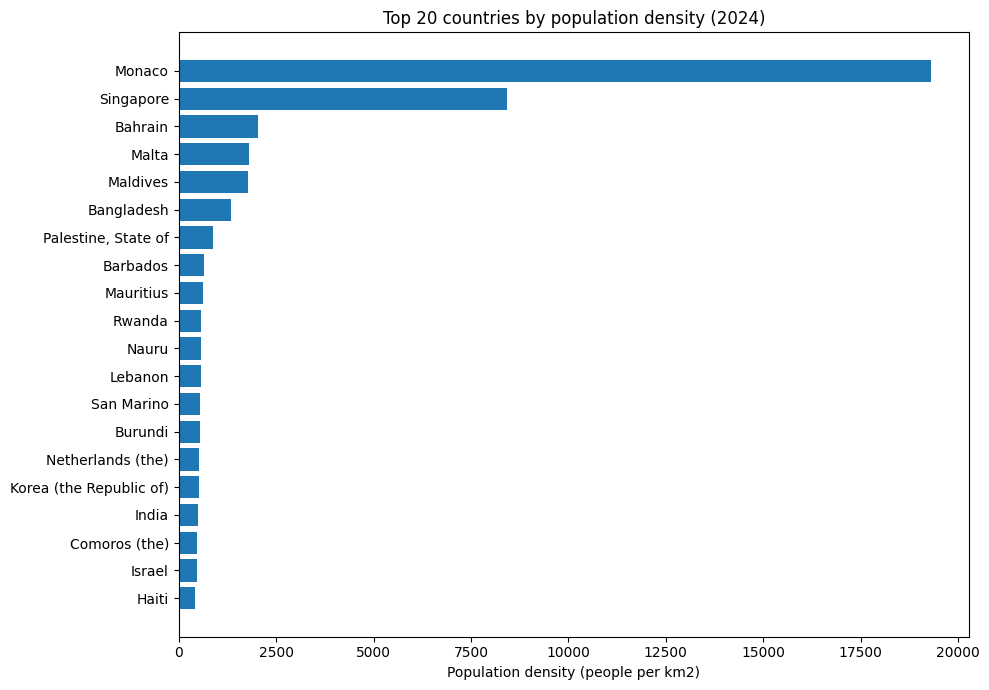

In [14]:
pdf = top20_density.to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["pop_density"])
ax.set_xlabel("Population density (people per km2)")
ax.set_title("Top 20 countries by population density (2024)")
plt.tight_layout()
plt.show()

## Land Area vs Population

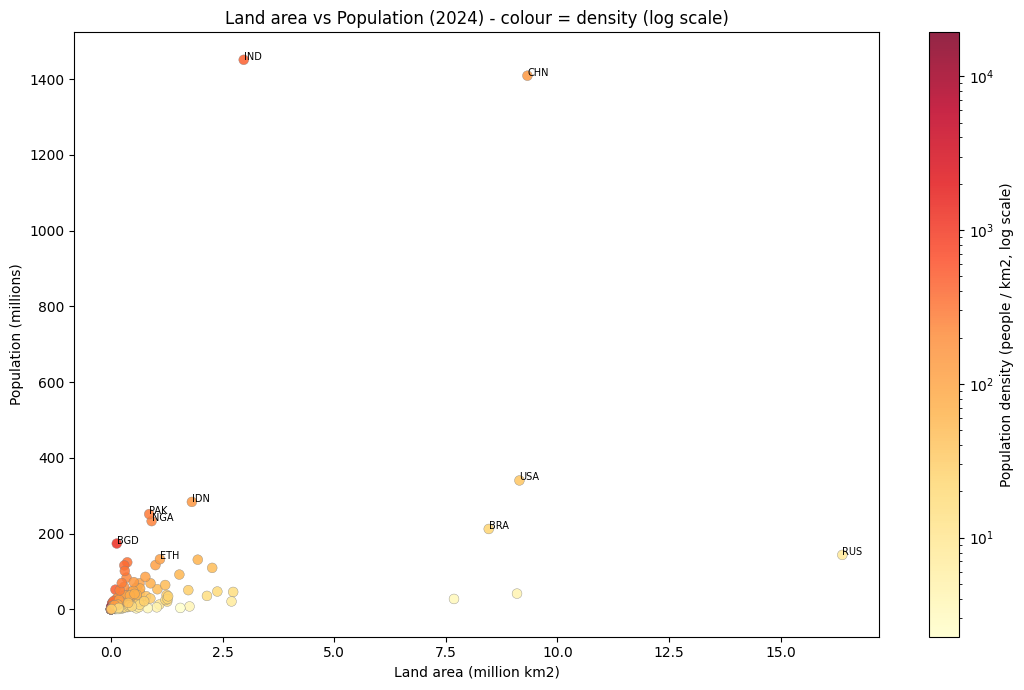

In [15]:
plot_df = (
    df.filter(
        (pl.col("land") > 0)
        & pl.col("population").is_not_null()
        & pl.col("pop_density").is_not_null()
    )
    .select("english_short_name", "alpha_3_code", "land", "population", "pop_density")
    .to_pandas()
)

norm = mcolors.LogNorm(vmin=plot_df["pop_density"].min(), vmax=plot_df["pop_density"].max())

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    plot_df["land"] / 1_000_000,
    plot_df["population"] / 1_000_000,
    c=plot_df["pop_density"],
    cmap="YlOrRd",
    norm=norm,
    s=50,
    alpha=0.85,
    edgecolors="grey",
    linewidths=0.3,
)

plt.colorbar(sc, ax=ax, label="Population density (people / km2, log scale)")
ax.set_xlabel("Land area (million km2)")
ax.set_ylabel("Population (millions)")
ax.set_title("Land area vs Population (2024) - colour = density (log scale)")

for _, row in plot_df.nlargest(10, "population").iterrows():
    ax.annotate(
        row["alpha_3_code"],
        xy=(row["land"] / 1_000_000, row["population"] / 1_000_000),
        fontsize=7,
        ha="left",
    )

plt.tight_layout()
plt.show()

## GDP

In [16]:
# 10 largest economies by GDP
df.sort("gdp_usd", descending=True, nulls_last=True).select(
    "english_short_name", "alpha_3_code", "gdp_usd", "gdp_year"
).head(10)

english_short_name,alpha_3_code,gdp_usd,gdp_year
str,str,i64,i64
"""United States of America (the)""","""USA""",28750956130731,2024
"""China""","""CHN""",18743803170827,2024
"""Germany""","""DEU""",4685592577804,2024
"""Japan""","""JPN""",4027597523550,2024
"""India""","""IND""",3909891533858,2024
"""United Kingdom of Great Britai…","""GBR""",3686033044482,2024
"""France""","""FRA""",3160442622465,2024
"""Italy""","""ITA""",2380825077243,2024
"""Canada""","""CAN""",2243636826633,2024


In [17]:
top20_gdp = (
    df.sort("gdp_usd", descending=True, nulls_last=True)
    .head(20)
    .sort("gdp_usd")
    .select("english_short_name", (pl.col("gdp_usd") / 1_000_000_000_000).alias("gdp_trillion_usd"))
)

top20_gdp

english_short_name,gdp_trillion_usd
str,f64
"""Switzerland""",0.936564
"""Netherlands (the)""",1.214928
"""Saudi Arabia""",1.239805
"""Türkiye""",1.359124
"""Indonesia""",1.3963
…,…
"""India""",3.909892
"""Japan""",4.027598
"""Germany""",4.685593


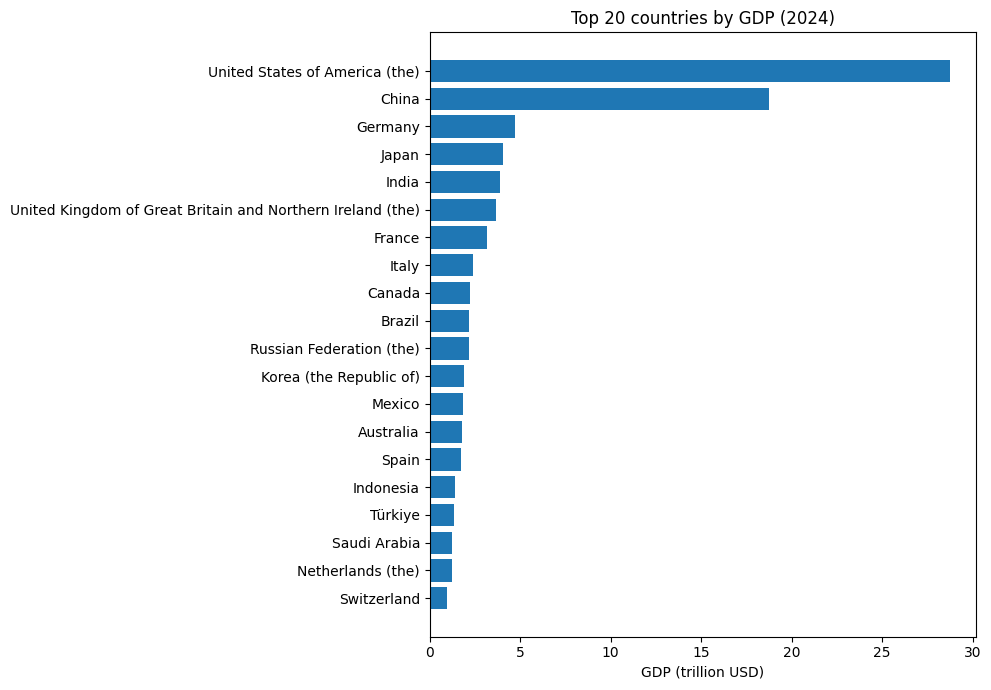

In [18]:
pdf = top20_gdp.to_pandas()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(pdf["english_short_name"], pdf["gdp_trillion_usd"])
ax.set_xlabel("GDP (trillion USD)")
ax.set_title("Top 20 countries by GDP (2024)")
plt.tight_layout()
plt.show()